<a href="https://colab.research.google.com/github/parthakk07/ML-learning/blob/main/try.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### `Task` How dimensionality reduction using Principal Component Analysis (PCA) on the Wine Quality dataset contributes to improving the classification accuracy and efficiency of wine type.

Note : Use KNN for Classification.

Data Link :  [Wine Data](https://docs.google.com/spreadsheets/d/e/2PACX-1vQDVwxneOKOaJL13QMhkAhYrgWlH1tICY7RacUnj_lL8m9uUWaaUf3p7bScNyh_D2Rvt7nc1q11adSy/pub?gid=647503637&single=true&output=csv)

In [93]:
# Data Loading
import pandas as pd
wine_data_path = "https://docs.google.com/spreadsheets/d/e/2PACX-1vQDVwxneOKOaJL13QMhkAhYrgWlH1tICY7RacUnj_lL8m9uUWaaUf3p7bScNyh_D2Rvt7nc1q11adSy/pub?gid=647503637&single=true&output=csv"
wine = pd.read_csv(wine_data_path)
wine

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.270,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6
1,white,6.3,0.300,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6
2,white,8.1,0.280,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6
3,white,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
4,white,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,red,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
6493,red,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,NaN,11.2,6
6494,red,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
6495,red,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [ ]:
# Your Code goes Here

In [94]:
wine.isnull().mean()

,0
type,0.000000
fixed acidity,0.001539
volatile acidity,0.001231
citric acid,0.000462
residual sugar,0.000308
chlorides,0.000308
free sulfur dioxide,0.000000
total sulfur dioxide,0.000000
density,0.000000
pH,0.001385


In [95]:
wine.dropna(inplace=True)

In [96]:
x=wine.drop(["quality"],axis=1)
y=wine["quality"]

In [97]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [98]:
X_train

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
459,white,6.1,0.43,0.35,9.1,0.059,83.0,249.0,0.99710,3.37,0.50,8.500000
1460,white,8.5,0.17,0.74,3.6,0.050,29.0,128.0,0.99280,3.28,0.40,12.400000
4403,white,5.2,0.22,0.46,6.2,0.066,41.0,187.0,0.99362,3.19,0.42,9.733333
3828,white,6.3,0.40,0.24,5.1,0.036,43.0,131.0,0.99186,3.24,0.44,11.300000
4317,white,6.7,0.34,0.26,1.9,0.038,58.0,138.0,0.98930,3.00,0.47,12.200000
...,...,...,...,...,...,...,...,...,...,...,...,...
3798,white,7.9,0.21,0.39,2.0,0.057,21.0,138.0,0.99176,3.05,0.52,10.900000
5219,red,9.3,0.61,0.26,3.4,0.090,25.0,87.0,0.99975,3.24,0.62,9.700000
5254,red,11.5,0.41,0.52,3.0,0.080,29.0,55.0,1.00010,3.26,0.88,11.000000
5418,red,9.8,0.25,0.49,2.7,0.088,15.0,33.0,0.99820,3.42,0.90,10.000000


In [99]:
X_train["type"].unique()

array(['white', 'red'], dtype=object)

In [59]:
X_train.isnull().mean()

,0
type,0.000000
fixed acidity,0.001347
volatile acidity,0.001155
citric acid,0.000385
residual sugar,0.000192
chlorides,0.000192
free sulfur dioxide,0.000000
total sulfur dioxide,0.000000
density,0.000000
pH,0.001732


In [100]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
transform=ColumnTransformer([("scaler",StandardScaler(),["fixed acidity","volatile acidity","citric acid","residual sugar","chlorides","free sulfur dioxide","total sulfur dioxide","density","pH","sulphates","alcohol"]),("oh",OneHotEncoder(drop="first"),["type"])],remainder="passthrough")

In [101]:
X_train_trf=transform.fit_transform(X_train)
X_test_trf=transform.transform(X_test)

In [102]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier()
knn.fit(X_train_trf,Y_train)

KNeighborsClassifier()

In [103]:
y_pred=knn.predict(X_test_trf)


In [104]:
from sklearn.metrics import accuracy_score
accuracy_score(Y_test,y_pred)

0.559938128383604

In [86]:
from sklearn.decomposition import PCA
pca=PCA()
X_train_trf=pca.fit_transform(X_train_trf)
X_test_trf=pca.fit_transform(X_test_trf)


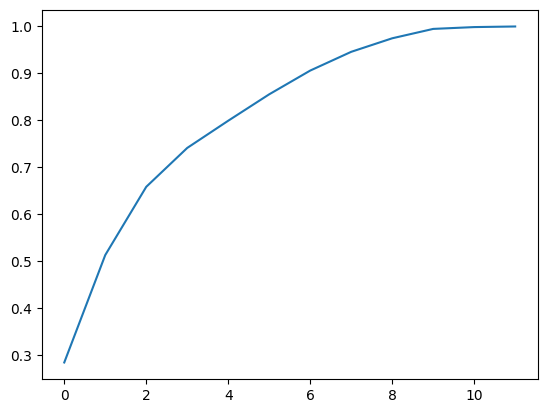

In [92]:
import matplotlib.pyplot as plt
import numpy as np b
plt.plot(np.cumsum(pca.explained_variance_ratio_))

In [105]:
from sklearn.decomposition import PCA
pca=PCA(n_components=8)
X_train_trf=pca.fit_transform(X_train_trf)
X_test_trf=pca.fit_transform(X_test_trf)


In [106]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier()
knn.fit(X_train_trf,Y_train)

KNeighborsClassifier()

In [107]:
y_pred2=knn.predict(X_train_trf)

In [108]:
accuracy_score(Y_train,y_pred2)

0.7090909090909091

In [109]:
# 70 cercent